# Structuring Qualitative Data with NLP: REDSAG Study

This project aims to transform qualitative survey responses into structured and analyzable data using Natural Language Processing (NLP). The data comes from a survey conducted among member organizations of REDSAG, a network coordinating actors in sustainable and agroecological food systems in Guatemala.

The dataset consists of open-ended responses collected to support a broader strategic planning process. Due to their unstructured nature, these qualitative inputs require preprocessing and transformation before they can be used in analytical frameworks.

The objective of this project is to build a robust NLP pipeline to clean, process, and structure the text data, enabling downstream use in strategic tools such as SWOT and RACI, with the ultimate goal of supporting a strategic planning exercise for REDSAG.

This notebook focuses on data preparation, text preprocessing, and initial structuring steps to make qualitative insights usable for further analysis.

**Author**: J-F Jutras  
**Date**: April 2026  
**Dataset**: REDSAG Member Organizations Survey (Qualitative Responses)

## 1-Data Loading and Overview

In [224]:
import pandas as pd

# File path (Kaggle uploaded dataset)
file_path = "/kaggle/input/datasets/jfjutras07/respuestas-redsag/Respuestas_REDSAG.xlsx"

# Load dataset
df = pd.read_excel(file_path)

# Preview
display(df.head())

# Clone the public GitHub repository "jfj-utils"
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to path
import sys
sys.path.append("/kaggle/working/jfj-utils")

,Horodateur,Nombre de la organización,Tipo de organización,"Si respondió “Otro” en la pregunta anterior, por favor especifique.",Región donde trabaja principalmente,Número aproximado de personas beneficiarias o miembros,Principales ejes estratégicos en sus áreas de trabajo (seleccione máximo 5),"Si respondió “Otro” en la pregunta anterior, por favor especifique. 2",¿Cuáles son los principales proyectos o iniciativas que su organización está implementando actualmente?,¿Con qué actores trabajan principalmente en estos proyectos?,...,¿Qué tipo de apoyo sería más útil por parte de REDSAG?,"Si respondió “Otro” en la pregunta anterior, por favor especifique. 6",Describa brevemente el apoyo que sería más útil para su organización por parte de REDSAG.,¿Qué responsabilidades cree que debería tener REDSAG con su organización y las organizaciones que la integran?,¿Qué responsabilidades deberían permanecer principalmente en las organizaciones miembros?,¿En qué áreas cree que existe confusión de roles entre REDSAG y las organizaciones miembros?,¿Cuál cree que debería ser la prioridad principal que debería atender el próximo plan estratégico de la REDSAG en los próximos 3 años?,¿Qué oportunidades de colaboración existen entre las organizaciones de la red que aún no se están aprovechando?,¿Puede mencionar un ejemplo reciente donde los roles entre REDSAG y las organizaciones no estaban claros?,¿Hay algo más que le gustaría compartir sobre el funcionamiento de la red o la colaboración entre las organizaciones?
0,2026-03-16 10:05:35.097,ONG LOQ´LAJ CH´OCH´ - Sagrada Tierra,ONG local,NaN,Petén,Más de 100,"Producción agroecológica, Fortalecimiento orga...",NaN,"Proyectos sobre Derecho al agua y saneamiento,...",Comunidades rurales,...,"Formación tecnica, Gestión de financiamiento, ...",NaN,Continuar con los espacios para participar en ...,"Mantener las relaciones existentes, así como l...",Cumplir con los compromisos que se adquieren c...,No he observado confusión en los Roles de REDS...,Me parece que debe continuar con 3 de las líne...,Sería interesante que personal de la Redsag co...,Como indique en respuesta anterior al tema de ...,Me interesaría saber como podemos actuar en co...
1,2026-03-16 21:07:50.898,Mejorha,ONG local,NaN,Oriente,Más de 100,"Producción agroecológica, Soberanía alimentari...",NaN,Soberanía alimentaría,Comunidades rurales,...,"Coordinación de proyectos, Incidencia política...",NaN,Asesoría y acompañamiento financiamiento,Acompañamiento,Cumplir con los reglamentos de como manejamos ...,No se reconocen como Red,Trabajar en consorcio,Las formaciones,Que todos somos redsag,Que estamos luchando por nuestra soberanía ali...
2,2026-03-16 21:13:37.529,Asociacion Civil no Lucrativa para el Desarrol...,Otro (especificar),Asociacion,Oriente,25 - 50,Medio ambiente y gestión de bienes naturales,NaN,"Proteccion, restauracion de nuestro bosque",ONG internacionales,...,"Incidencia política, Formación tecnica, Comuni...",NaN,Incidencia politica,Apoyo tecnico,Participacion,Apoyo economico,Acompañamiento politico y tecnico,Talleres de formacion,El tipo de acompañamiento,A larar la funcion principal de Redsag
3,2026-03-17 11:47:17.517,Asoc. De desarrollo Integra Ri Aj Poop B'atz',Organización comunitaria,NaN,Verapaces,51 - 100,"Producción agroecológica, Desarrollo económico...",NaN,"Huerto familiar, agroecologia y tejidos",Cooperativas u organizaciones campesinas,...,"Coordinación de proyectos, Articulación entre ...",NaN,"La coordinacion y articulación, que van de la ...",El apoyo continuo con una buena organización p...,Participación activa y fomentar/compartir los ...,Como suplente de consejo politico,Que apoye las organizaciones que forman parte ...,Realizan mercados comunitarios y no esta aprov...,Cuando no aprovechan el momento de la asamblea...,Producir mas afiches para dar a las organizaci...
4,2026-03-17 12:58:40.275,Coordinadora de Organización de Mujeres de Alt...,ONG local,NaN,Verapaces,Más de 100,"Producción agroecológica, Sobera

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 3527 (delta 231), reused 99 (delta 99), pack-reused 3240 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 19.53 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


## 2-Context of the Assignment

REDSAG is a coordination network that brings together more than sixty member organizations working across agroecology, food systems, and rural development in Guatemala. As part of an ongoing strategic planning process, the network is seeking to better align its collective actions and strengthen collaboration among members. However, this process is currently challenged by unclear role definitions between REDSAG and its member organizations, as well as a lack of consolidated and structured data to support decision-making. 

This survey was designed to address these gaps by capturing qualitative and quantitative insights on organizational profiles, activities, challenges, and expectations, in order to inform both a RACI workshop on roles and responsibilities and the broader strategic planning exercise.

## 3-Survey Structure

This survey includes 20 questions addressed to member organizations of REDSAG to better understand their profiles, activities, challenges, and collaboration dynamics within the network. It combines both closed-ended questions (organizational type, region, size, areas of work, partners, and types of support) and open-ended questions on ongoing projects, key challenges, perceived roles, and strategic priorities. The responses aim to identify needs and opportunities for collaboration, clarify roles between REDSAG and its members in preparation for a RACI workshop, and support a broader participatory strategic planning process for the network.

| Section | Objective | Question Type | Content |
|----------|----------|----------------|----------|
| 1. General information | Profile of member organizations | Closed (multiple choice) | Organization type, region, size, main areas of work |
| 2. Projects and initiatives | Understand ongoing activities and collaboration | Open + closed | Current projects, partners, role of REDSAG in projects |
| 3. Challenges and needs | Identify barriers and support needs | Open + closed | Main challenges, support needs, expectations from REDSAG |
| 4. Coordination and roles (RACI) | Clarify responsibilities within the network | Open-ended | Roles of REDSAG, roles of member organizations, areas of confusion |
| 5. Vision and improvements | Inform strategic planning | Open-ended | Strategic priorities, collaboration opportunities, network improvements |

## 4-Data Cleaning and Transforming

### Column Renaming

In [225]:
# Rename all columns manually to ensure consistency and avoid issues 
# with spaces, accents, or special characters

df.columns = [
    "marca_tiempo",                 # Survey submission time
    "nombre_organizacion",         # Name of the organization
    "tipo_organizacion",           # Type of organization
    "tipo_organizacion_otro",      # "Other" specification for org type
    "region",                      # Main region of activity
    "tamano_organizacion",         # Approximate number of beneficiaries/members
    "ejes_estrategicos",          # Main strategic areas (multi-select)
    "ejes_estrategicos_otro",     # "Other" specification for strategic axes
    "proyectos",                  # Current projects or initiatives
    "socios",                     # Main partners involved
    "socios_otro",               # "Other" specification for partners
    "apoyo_recibido",           # Types of support received from REDSAG
    "apoyo_recibido_otro",     # "Other" specification for support received
    "descripcion_apoyo_recibido",  # Description of support received
    "desafios",                # Main challenges (multi-select)
    "desafios_otro",          # "Other" specification for challenges
    "principal_desafio",     # Most important challenge (open text)
    "apoyo_necesario",      # Types of support needed
    "apoyo_necesario_otro", # "Other" specification for support needed
    "descripcion_apoyo_necesario",  # Description of support needed
    "rol_redsag",               # Expected role of REDSAG
    "rol_miembros",            # Expected role of member organizations
    "confusion_roles",        # Areas of role confusion
    "prioridad_estrategica",  # Key strategic priority for next 3 years
    "oportunidades_colaboracion",  # Opportunities for collaboration
    "ejemplo_rol",              # Example of unclear roles
    "comentarios_adicionales"   # Additional comments
]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   marca_tiempo                 36 non-null     datetime64[ns]
 1   nombre_organizacion          36 non-null     object        
 2   tipo_organizacion            36 non-null     object        
 3   tipo_organizacion_otro       11 non-null     object        
 4   region                       36 non-null     object        
 5   tamano_organizacion          36 non-null     object        
 6   ejes_estrategicos            36 non-null     object        
 7   ejes_estrategicos_otro       2 non-null      object        
 8   proyectos                    36 non-null     object        
 9   socios                       36 non-null     object        
 10  socios_otro                  5 non-null      object        
 11  apoyo_recibido               36 non-null     ob

We collected 36 responses out of 67 targeted organizations (53.7%). The dataset includes both closed-ended and open-ended questions covering organizational profiles, activities, challenges, and collaboration dynamics within REDSAG. “Other” fields are used as extensions of previous categorical questions and will be merged back into their respective categories to preserve meaning and consistency. The dataset will then be cleaned for missing values and structural inconsistencies before moving on to content analysis and thematic exploration.

### Handling Missing Values and Category Cleaning

In [226]:
# Drop timestamp column (not needed for analysis)
df = df.drop(columns=["marca_tiempo"], errors="ignore")

# Fill missing values in all text columns
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].fillna("")

# Function to merge "other" responses into main column
def merge_other(main_col, other_col):
    df[main_col] = df.apply(
        lambda row: (
            row[main_col] + ", " + row[other_col]
            if row[other_col] and row[other_col] not in row[main_col]
            else row[main_col]
        ),
        axis=1
    )

# Merge all "other" columns
merge_other("tipo_organizacion", "tipo_organizacion_otro")
merge_other("ejes_estrategicos", "ejes_estrategicos_otro")
merge_other("socios", "socios_otro")
merge_other("apoyo_recibido", "apoyo_recibido_otro")
merge_other("desafios", "desafios_otro")
merge_other("apoyo_necesario", "apoyo_necesario_otro")

# Drop "other" columns after merging
df = df.drop(columns=[
    "tipo_organizacion_otro",
    "ejes_estrategicos_otro",
    "socios_otro",
    "apoyo_recibido_otro",
    "desafios_otro",
    "apoyo_necesario_otro"
])

# Clean categorical text (remove duplicates and normalize format)
def clean_categories(text):
    items = [i.strip().lower() for i in text.split(",") if i.strip()]
    
    seen = set()
    cleaned = []
    for item in items:
        if item not in seen:
            seen.add(item)
            cleaned.append(item)
    
    return ", ".join(cleaned)

# Apply cleaning to categorical columns
category_cols = [
    "tipo_organizacion",
    "ejes_estrategicos",
    "socios",
    "apoyo_recibido",
    "desafios",
    "apoyo_necesario"
]

for col in category_cols:
    df[col] = df[col].apply(clean_categories)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   nombre_organizacion          36 non-null     object
 1   tipo_organizacion            36 non-null     object
 2   region                       36 non-null     object
 3   tamano_organizacion          36 non-null     object
 4   ejes_estrategicos            36 non-null     object
 5   proyectos                    36 non-null     object
 6   socios                       36 non-null     object
 7   apoyo_recibido               36 non-null     object
 8   descripcion_apoyo_recibido   36 non-null     object
 9   desafios                     36 non-null     object
 10  principal_desafio            36 non-null     object
 11  apoyo_necesario              36 non-null     object
 12  descripcion_apoyo_necesario  36 non-null     object
 13  rol_redsag                   36 non-n

In [227]:
# Remove obvious noise from categorical fields
noise_terms = [
    "no aplica",
    "otro (especificar)"
]

def clean_categories_advanced(text):
    items = [i.strip().lower() for i in text.split(",") if i.strip()]
    
    cleaned = []
    for item in items:
        if item not in noise_terms:
            cleaned.append(item)
    
    return ", ".join(cleaned)

# Apply light cleaning
for col in [
    "tipo_organizacion",
    "ejes_estrategicos",
    "socios",
    "apoyo_recibido",
    "desafios",
    "apoyo_necesario"
]:
    df[col] = df[col].apply(clean_categories_advanced)

In [228]:
# Show unique categories for each categorical column
for col in category_cols:
    print(f"\n{col}:\n")
    print(df[col].str.split(", ").explode().unique())


tipo_organizacion:

['ong local' 'asociacion' 'organización comunitaria'
 'unidad de mueres en desarrollo' 'local en casa oy sembradios'
 'asociación campesina' 'asociación civil'
 'red u organización de segundo nivel' 'congcoop' 'plataforma urbana'
 'asociacion comunitaria' 'colectivo de voluntarios'
 'equipo de facilitación']

ejes_estrategicos:

['producción agroecológica' 'fortalecimiento organizativo y gobernanza'
 'medio ambiente y gestión de bienes naturales' 'educación'
 'formación e intercambio de conocimientos'
 'equidad de género y liderazgo de mujeres' 'cultura'
 'saberes ancestrales y pueblos indígenas'
 'soberanía alimentaria y sistemas alimentarios' 'salud comunitaria'
 'desarrollo económico'
 'comercialización y acceso a mercados (economía comunitaria)'
 'incidencia política y defensa de derechos' 'juventud rural'
 'semillas y biodiversidad' 'investigación' 'solo organico cosrchamos']

socios:

['comunidades rurales' 'ong internacionales'
 'cooperativas u organizacione

In [229]:
# Standardization + noise removal for categorical variables
# Mapping dictionaries (fully standardized in Spanish)
mapping = {
    "tipo_organizacion": {
        "ong local": "ong local",
        "asociacion": "asociacion",
        "asociación comunitaria": "asociacion comunitaria",
        "asociacion comunitaria": "asociacion comunitaria",
        "asociación campesina": "asociacion campesina",
        "asociación civil": "asociacion civil",
        "organización comunitaria": "organizacion comunitaria",
        "red u organización de segundo nivel": "red organizativa",
        "plataforma urbana": "red organizativa",
        "congcoop": "red organizativa",
        "colectivo de voluntarios": "colectivo de voluntarios",
        "equipo de facilitación": "equipo de facilitacion",
        "unidad de mueres en desarrollo": "unidad de mujeres en desarrollo",
        "local en casa oy sembradios": "iniciativa local"
    },

    "ejes_estrategicos": {
        "producción agroecológica": "produccion agroecologica",
        "soberanía alimentaria y sistemas alimentarios": "soberania alimentaria",
        "medio ambiente y gestión de bienes naturales": "medio ambiente",
        "incidencia política y defensa de derechos": "incidencia politica",
        "comercialización y acceso a mercados (economía comunitaria)": "acceso a mercados",
        "educación": "educacion",
        "formación e intercambio de conocimientos": "formacion e intercambio de conocimientos",
        "equidad de género y liderazgo de mujeres": "equidad de genero",
        "cultura": "cultura",
        "saberes ancestrales y pueblos indígenas": "saberes ancestrales",
        "salud comunitaria": "salud comunitaria",
        "desarrollo económico": "desarrollo economico",
        "juventud rural": "juventud rural",
        "semillas y biodiversidad": "semillas y biodiversidad",
        "investigación": "investigacion"
    },

    "socios": {
        "comunidades rurales": "comunidades",
        "comunidades rurales y en el centro urbano de quetzaltenango.": "comunidades",
        "ong internacionales": "ong",
        "cooperativas u organizaciones campesinas": "cooperativas",
        "universidades o centros de investigación": "academia",
        "emprendimiento propio de mujeres": "grupos de mujeres",
        "fondo de tierra .": "gobierno"
    },

    "apoyo_recibido": {
        "intercambio de conocimientos o experiencias": "intercambio de conocimientos",
        "intercambio de experiencias": "intercambio de conocimientos",
        "formación o fortalecimiento de capacidades": "formacion",
        "facilitación de alianzas o redes": "articulacion",
        "coordinación entre organizaciones": "coordinacion",
        "apoyo técnico": "apoyo tecnico",
        "incidencia política o reprsentación": "incidencia politica",
        "comunicación y visibilidad": "comunicacion",
        "movilización o gestión de financiamiento": "financiamiento",
        "apoyo logístico u organizativo": "apoyo logistico"
    },

    "desafios": {
        "financiamiento": "financiamiento",
        "coordinación entre organizaciones": "coordinacion",
        "capacidades técnicas": "capacidad tecnica",
        "incidencia política": "incidencia politica",
        "participación comunitaria": "participacion comunitaria",
        "acceso a mercados": "acceso a mercados",
        "comunicación": "comunicacion",
        "prevención de violencia": "prevencion de violencia"
    },

    "apoyo_necesario": {
        "formación tecnica": "formacion tecnica",
        "gestión de financiamiento": "financiamiento",
        "articulación entre organizaciones": "coordinacion",
        "coordinación de proyectos": "coordinacion de proyectos",
        "cordinación de proyectos": "coordinacion de proyectos",
        "incidencia política": "incidencia politica",
        "comunicación y visibilidad": "comunicacion",
        "seguridad física y digital": "seguridad fisica y digital"
    }
}

# Noise terms (non-informative responses)
noise = set([
    "solo organico cosrchamos",
    "trabajanos aria rural",
    "se a manejado los intercambios entre los compañeros",
    "no hemos participado mucho últimamente",
    "las acciones que nos interesaban participar son principalmente los intercambios de semillas y mercadoss",
    "solo las capacitasiones",
    "lograr apoyo para mantener la educación de jóvenes en el iebacedeco acm",
    "preparar a otra jeneraciones a produsir organico",
    "no aplica.",
    "no aplica",
    ""
])

# Cleaning function
def standardize(text, col):
    if not isinstance(text, str):
        return ""

    items = [i.strip().lower() for i in text.split(",") if i.strip()]

    cleaned = []
    for item in items:
        if item in noise:
            continue

        if col in mapping and item in mapping[col]:
            cleaned.append(mapping[col][item])
        else:
            cleaned.append(item)

    return ", ".join(dict.fromkeys(cleaned))

# Columns to clean
cols_to_clean = [
    "tipo_organizacion",
    "ejes_estrategicos",
    "socios",
    "apoyo_recibido",
    "desafios",
    "apoyo_necesario"
]

# Apply cleaning
for col in cols_to_clean:
    df[col] = df[col].fillna("").apply(lambda x: standardize(x, col))

In [230]:
# Quick check

for col in category_cols:
    print(f"\n{col}:\n")
    print(df[col].str.split(", ").explode().unique())


tipo_organizacion:

['ong local' 'asociacion' 'organizacion comunitaria'
 'unidad de mujeres en desarrollo' 'iniciativa local'
 'asociacion campesina' 'asociacion civil' 'red organizativa'
 'asociacion comunitaria' 'colectivo de voluntarios'
 'equipo de facilitacion']

ejes_estrategicos:

['produccion agroecologica' 'fortalecimiento organizativo y gobernanza'
 'medio ambiente' 'educacion' 'formacion e intercambio de conocimientos'
 'equidad de genero' 'cultura' 'saberes ancestrales'
 'soberania alimentaria' 'salud comunitaria' 'desarrollo economico'
 'acceso a mercados' 'incidencia politica' 'juventud rural'
 'semillas y biodiversidad' 'investigacion']

socios:

['comunidades' 'ong' 'cooperativas' 'grupos de mujeres' 'academia'
 'gobierno']

apoyo_recibido:

['coordinacion' 'articulacion' 'formacion' 'intercambio de conocimientos'
 'incidencia politica' 'apoyo tecnico' 'comunicacion' 'financiamiento'
 'apoyo logistico']

desafios:

['financiamiento' 'coordinacion' 'capacidad tecnica' 

In [231]:
#Count values in cols_to_clean
import pandas as pd

# Split + explode
def explode_counts(df, col):
    return (
        df[col]
        .dropna()
        .astype(str)
        .str.split(",")          # split multi-labels
        .explode()               # one item per row
        .str.strip()             # clean spaces
        .value_counts()
    )

#Run all counts
for col in cols_to_clean:
    print("\n" + "="*40)
    print(f"TOP VALUES — {col}")
    print("="*40)
    print(explode_counts(df, col).head(30))


TOP VALUES — tipo_organizacion
tipo_organizacion
ong local                          13
organizacion comunitaria            9
red organizativa                    4
asociacion campesina                3
asociacion civil                    2
asociacion                          1
iniciativa local                    1
unidad de mujeres en desarrollo     1
asociacion comunitaria              1
colectivo de voluntarios            1
equipo de facilitacion              1
Name: count, dtype: int64

TOP VALUES — ejes_estrategicos
ejes_estrategicos
soberania alimentaria                        27
produccion agroecologica                     25
equidad de genero                            21
medio ambiente                               20
incidencia politica                          19
educacion                                    18
formacion e intercambio de conocimientos     18
cultura                                      16
acceso a mercados                            16
saberes ancestrales     

The categorical variables have been sufficiently cleaned and structured to allow for meaningful analysis in a second phase, particularly given the relatively small sample size (approximately 36 responses across 67 organizations).

Despite minor remaining inconsistencies and a few residual mixed or overly specific entries, the data now shows clear and interpretable patterns across key dimensions such as organizational types, strategic axes, actors, support received and needed, and main challenges. This level of standardization is adequate to proceed with exploratory analysis, as the dominant categories are clearly identifiable and robust enough to support reliable insights at this stage.

### Text Cleaning

In [232]:
import re
import unicodedata

# Spanish stopwords
spanish_stopwords = set([
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para",
    "con","no","una","su","al","lo","como","pero","sus","le","ya","o",
    "este","sí","porque","esta","entre","cuando","muy","sin","sobre","también",
    "me","hasta","hay","donde","quien","desde","todo","nos","durante","todos",
    "uno","les","ni","contra","otros","ese","eso","ante","ellos","e","esto",
    "mí","antes","algunos","qué","unos","yo","otro","otras","otra", "mas", "menos"
])

# Custom stopwords specific to NGO / REDSAG context
custom_stopwords = set([
    "trabajo", "trabajar", "apoyo", "necesario", "necesarios",
    "hacer", "realizar", "forma", "nivel", "parte"
])

# Combine all stopwords
all_stopwords = spanish_stopwords.union(custom_stopwords)

# Optional normalization dictionary for common variations
normalization_map = {
    "agroecologica": "agroecologia",
    "agroecologico": "agroecologia",
    "formaciones": "formacion",
    "capacitacion": "formacion"
}

# Advanced Spanish text cleaning function
def clean_text_es_advanced(text):
    # Handle missing or non-string values
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Normalize unicode characters (preserve accents)
    text = unicodedata.normalize("NFKC", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    
    # Remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # Keep only alphabetic characters (including Spanish accents)
    text = re.sub(r"[^a-záéíóúñü\s]", " ", text)
    
    # Tokenize text
    words = text.split()
    
    # Normalize common word variations
    words = [normalization_map.get(w, w) for w in words]
    
    # Remove stopwords and short tokens
    words = [
        w for w in words
        if w not in all_stopwords and len(w) > 2
    ]
    
    # Reconstruct cleaned text
    return " ".join(words)

# Define open-ended text columns (avoid structured variables)
text_cols = [
    "descripcion_apoyo_recibido",
    "descripcion_apoyo_necesario",
    "principal_desafio",
    "comentarios_adicionales",
    "proyectos",
    "rol_redsag",
    "rol_miembros",
    "confusion_roles",
    "prioridad_estrategica",
    "oportunidades_colaboracion",
    "ejemplo_rol"
]

# Keep only columns that exist in the dataframe
valid_text_cols = [col for col in text_cols if col in df.columns]

# Apply cleaning
for col in valid_text_cols:
    df[col] = df[col].fillna("").apply(clean_text_es_advanced)

The cleaning and transformation process is sufficient to proceed with analysis, as it has resolved the main structural and semantic inconsistencies in the dataset. Categorical variables have been standardized through a consistent Spanish mapping, multi-label responses have been properly split and aggregated for reliable counting, and non-informative noise has been removed. Text variables were also cleaned to preserve meaning while eliminating irrelevant characters and formatting issues. 

Although minor inconsistencies remain, they do not affect the overall interpretability of patterns, especially given the small sample size and the exploratory and strategic nature of the analysis (EDA, RACI, SWOT). The dataset is therefore adequately structured and ready for meaningful analysis.

## 5-Survey Analysis

### Profile of Respondent Organizations

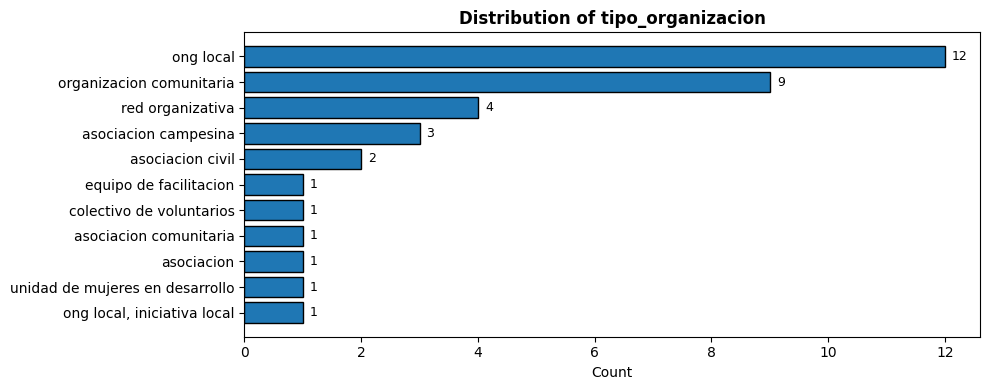

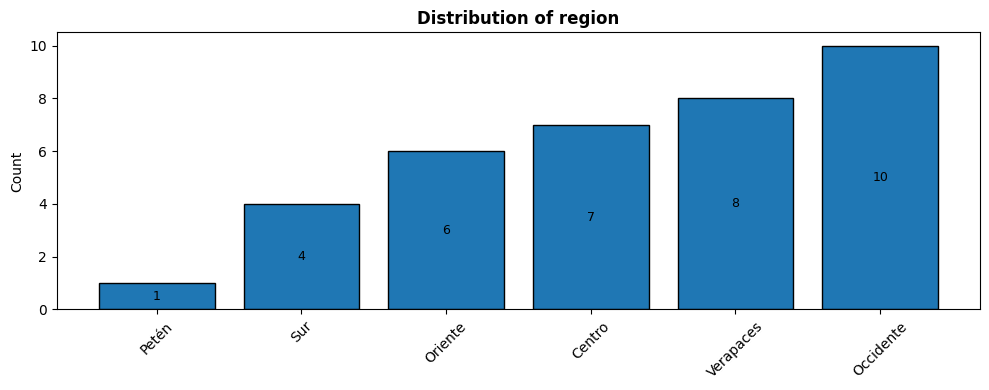

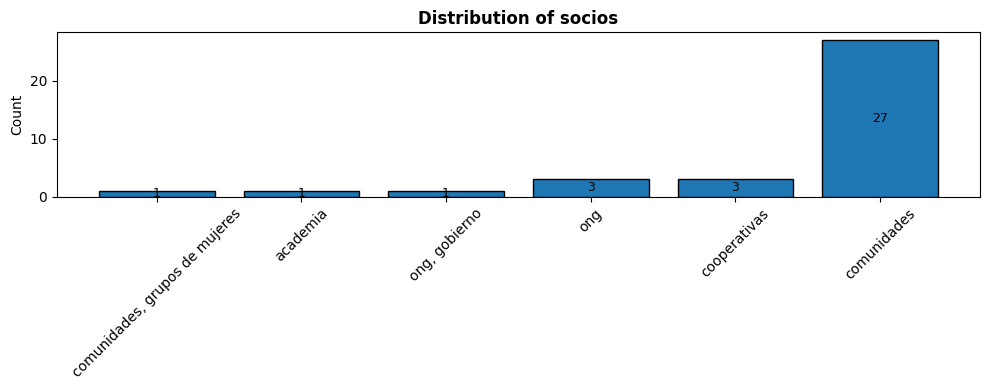

In [233]:
#Define columns to plot

profile_cols = ["tipo_organizacion", "region", "socios"]

from visualization.explore_discrete import plot_discrete_distribution
plot_discrete_distribution(df, profile_cols)

In [234]:
# Estimate total beneficiaries directly from 'tamano_organizacion'
total_benef = 0

for val in df["tamano_organizacion"].dropna():
    val = str(val).lower()
    
    if "menos de 25" in val:
        total_benef += 15
    elif "25" in val and "50" in val:
        total_benef += 37
    elif "51" in val and "100" in val:
        total_benef += 75
    elif "100" in val:
        total_benef += 150

print(f"Total estimado: {total_benef}")

Total estimado: 3612


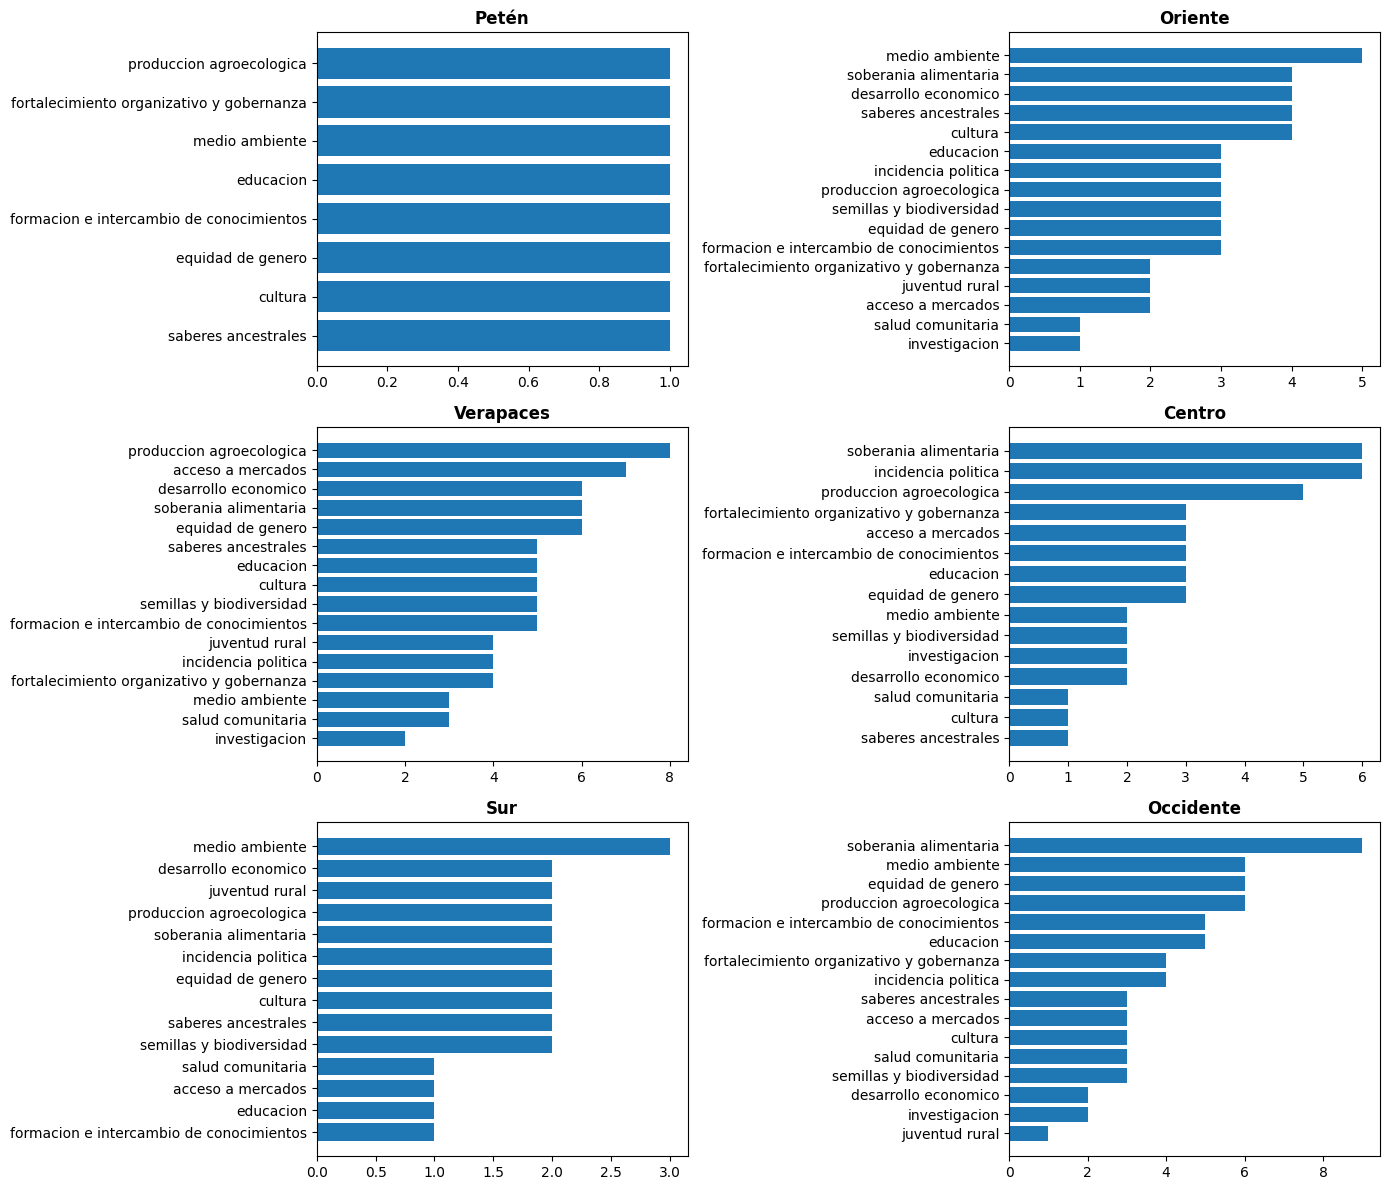

In [235]:
import math
import matplotlib.pyplot as plt

def plot_ejes_by_region(df, col, group_col, n_cols=2, figsize=(14, 10)):
    """
    Plot distribution of a multi-label categorical column grouped by region.
    Each subplot represents one region.
    """

    # Get unique regions
    regions = df[group_col].dropna().unique()

    # Create subplot grid
    n_rows = math.ceil(len(regions) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = axes.flatten()

    # Loop through each region
    for i, region in enumerate(regions):
        ax = axes_flat[i]

        # Filter data for region
        subset = df[df[group_col] == region]

        # Split multi-label column and count frequencies
        counts = (
            subset[col]
            .dropna()
            .astype(str)
            .str.split(",")
            .explode()
            .str.strip()
            .value_counts()
        )

        # Plot
        ax.barh(counts.index, counts.values)
        ax.set_title(region, fontweight="bold")
        ax.invert_yaxis()

    # Remove empty subplots
    for j in range(len(regions), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()

#Display
plot_ejes_by_region(
    df=df,
    col="ejes_estrategicos",
    group_col="region",
    n_cols=2,
    figsize=(14, 12)
)

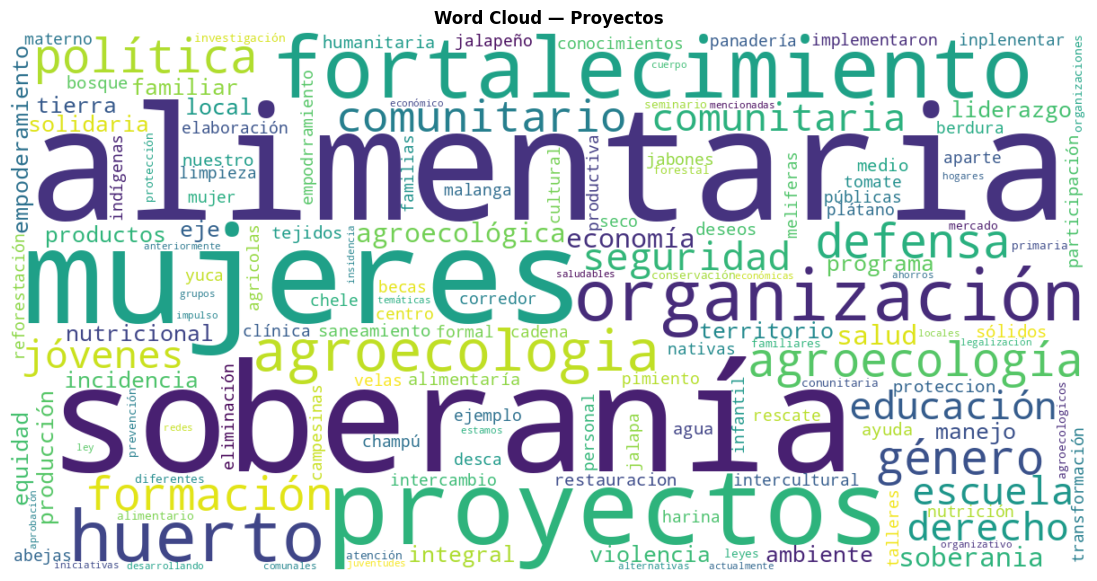

In [236]:
#WordCloud - Proyectos
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from "proyectos"
text = " ".join(df["proyectos"].fillna("").astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False  # avoids bigram noise repetition
).generate(text)

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Proyectos", fontweight="bold")
plt.show()


The organizational landscape is mainly composed of local NGOs (13) and community-based organizations (9), with additional but less frequent actors such as organizational networks and peasant associations. This distribution reflects a strongly grassroots-oriented system, where locally rooted and collective structures dominate over formal institutional organizations, indicating a decentralized and community-driven configuration.

The strategic framework is clearly centered on agroecological and territorial transformation. Food sovereignty (27), agroecological production (25), and gender equity (21) form the core priorities, followed by environmental protection (20) and political advocacy (19). Education, training, and knowledge exchange (18 each) also play a key role, highlighting the importance of capacity building, while economic development (17) and market access (16) reinforce an integrated approach combining productive, social, and territorial dimensions.

The partnership ecosystem is strongly dominated by local communities (28), confirming their central role in driving activities and territorial processes. NGOs (4) and cooperatives (3) play a secondary supporting role, while academia and government remain marginal. Overall, the system reflects a predominantly bottom-up structure, where community actors are the main pillar of coordination and implementation.

### Existing Support Mechanisms

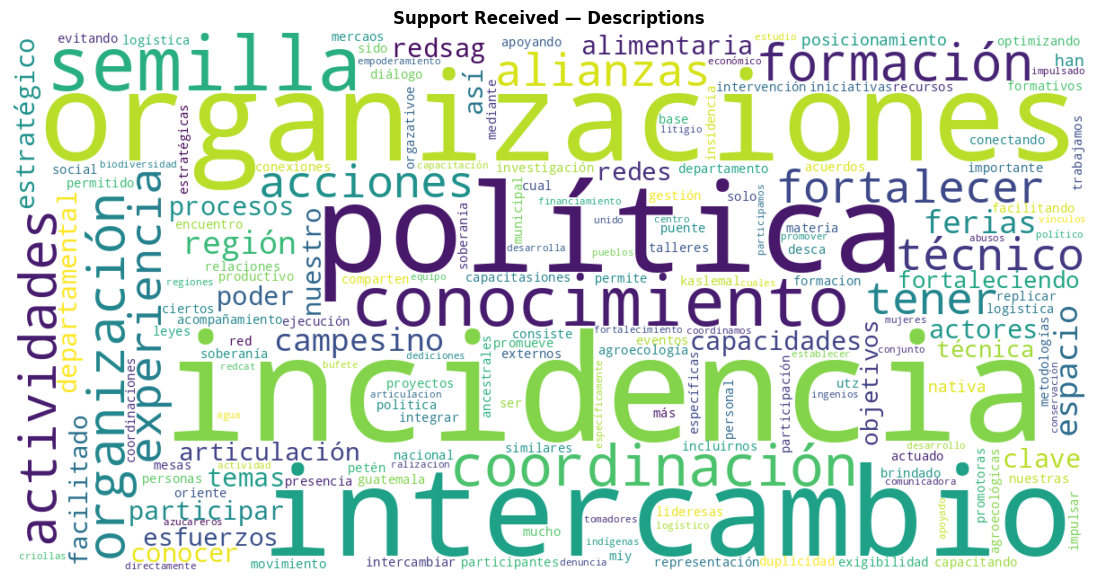

In [237]:
#WordCloud - Apoyo
text = " ".join(
    df["descripcion_apoyo_recibido"]
    .fillna("")
    .astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Support Received — Descriptions", fontweight="bold")
plt.show()

The analysis of existing support mechanisms reveals a system strongly oriented toward collaboration and knowledge exchange rather than direct material or financial assistance. The most frequent forms of support include knowledge sharing, coordination, articulation among actors, and capacity building activities. These elements indicate that the support ecosystem functions primarily as a relational and learning-oriented network.

In addition, support is rarely provided in isolated forms, but rather through combined packages integrating coordination, training, advocacy, and information exchange. This suggests a multi-functional support structure in which activities are interconnected and mutually reinforcing.

Overall, the role of REDSAG emerges as that of a strategic intermediary platform, facilitating connections between organizations, promoting collective learning processes, and strengthening network coherence rather than acting as a direct service provider.

### Key Challenges Faced by Organizations

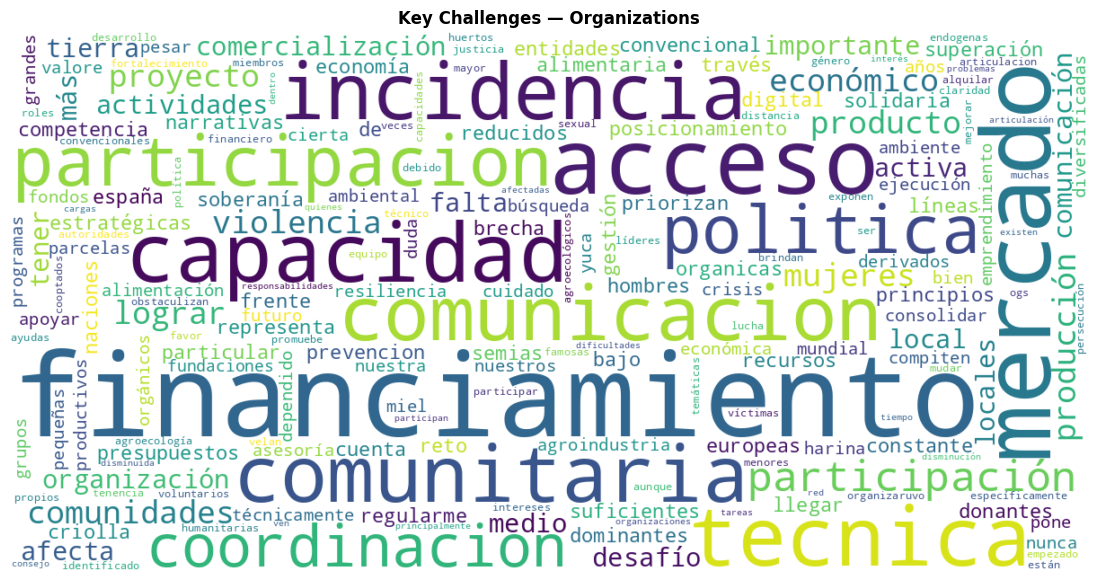

In [238]:
#WordCloud - Desafíos
text = " ".join(
    df["desafios"].fillna("").astype(str) + " " +
    df["principal_desafio"].fillna("").astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Key Challenges — Organizations", fontweight="bold")
plt.show()

The analysis of key challenges reveals a multi-layered constraint system affecting participating organizations. Financial limitations emerge as the most dominant issue, reflecting both direct funding shortages and broader dependency on external project-based financing. This financial constraint is closely linked to operational instability and limited organizational autonomy.

In parallel, access to markets represents a major structural barrier, highlighting the difficulty of integrating agroecological and locally produced goods into competitive and often conventional market systems. This creates a persistent tension between production models and market dynamics.

Organizational and coordination challenges also play a significant role, particularly in relation to technical capacity gaps, communication limitations, and difficulties in sustaining active community participation. These factors point to internal fragmentation and uneven institutional strengthening across actors.

Finally, broader structural constraints such as land tenure insecurity, digital divides, and limited political influence further exacerbate existing vulnerabilities. Overall, the challenges reflect an interconnected system where financial dependency, market exclusion, and organizational fragmentation reinforce each other.

### Unmet Needs and Required Support

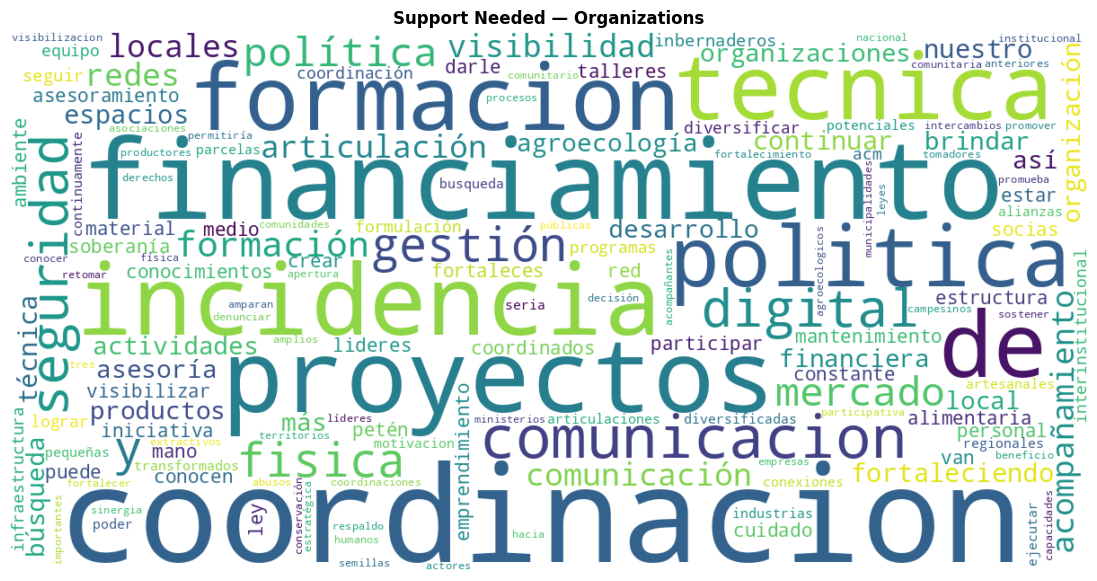

In [239]:
#WordCloud - Support
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    df["apoyo_necesario"].fillna("").astype(str) + " " +
    df["descripcion_apoyo_necesario"].fillna("").astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Support Needed — Organizations", fontweight="bold")
plt.show()

The analysis of support needs highlights coordination of projects as one of the most frequently mentioned requirements, often combined with financial support and technical training. This suggests that organizations are not only requesting resources but also stronger structuring and alignment mechanisms to improve project implementation and inter-organizational collaboration.

Financial support remains a central and structural need, frequently associated with project coordination and financial management capacities. The recurrence of this theme indicates a persistent dependency on external funding and a need for more stable and diversified financing strategies.

Capacity building also emerges as a key dimension of support needs, particularly in relation to technical training, advocacy, and communication. These elements reflect the need to strengthen both operational and strategic capabilities within organizations to improve effectiveness and influence.

Finally, several responses point to emerging needs such as visibility, infrastructure, market access, and even physical and digital security. These aspects suggest a broadening of organizational concerns beyond traditional project implementation, toward more systemic and long-term sustainability challenges.

**Gap Matrix**

The gap matrix compares “support received” versus “support needed” to identify structural mismatches between what organizations currently obtain and what they actually require. It highlights priority areas where system-level interventions are most urgent, especially where needs consistently exceed existing support.

| Dimension        | Support Received        | Support Needed        | Gap Intensity |
|----------------|------------------------|----------------------|---------------|
| Funding         | Medium (interchange, training support) | Very High (core dependency) | 🔴 Critical |
| Coordination    | High (articulation, exchange)          | Very High (project coordination) | 🟠 Structural |
| Training        | High (capacity building)               | High (technical strengthening) | 🟡 Moderate |
| Market Access   | Low                                   | Medium/High (commercialization) | 🔴 Emerging |
| Governance      | Medium (network support)               | High (strategic coordination, advocacy) | 🔴 Systemic |

### Perceived Role of REDSAG and Members

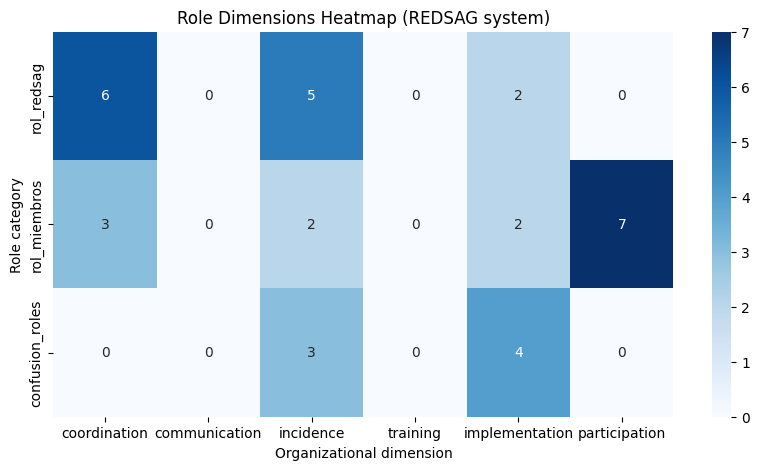

In [240]:
import seaborn as sns
role_cols = ["rol_redsag", "rol_miembros", "confusion_roles"]

dimensions = {
    "coordination": ["coordinacion", "articulacion", "acompañamiento"],
    "communication": ["comunicacion"],
    "incidence": ["incidencia", "politica"],
    "training": ["formacion", "capacitación", "tecnica"],
    "implementation": ["ejecucion", "proyectos"],
    "participation": ["participacion", "compromiso"]
}

# Function to compute score safely
def score_dimension(text_series, keywords):
    text = " ".join(text_series.fillna("").astype(str).str.lower())
    return sum(text.count(k) for k in keywords)

# Build matrix
matrix = []

for role in role_cols:
    row = {}
    
    for dim_name, keywords in dimensions.items():
        row[dim_name] = score_dimension(df[role], keywords)
    
    matrix.append(row)

heatmap_df = pd.DataFrame(matrix, index=role_cols)

# Plot
plt.figure(figsize=(10,5))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", fmt="d")
plt.title("Role Dimensions Heatmap (REDSAG system)")
plt.ylabel("Role category")
plt.xlabel("Organizational dimension")
plt.show()

The heatmap highlights a clear functional differentiation between roles within the REDSAG network. REDSAG is primarily associated with coordination, articulation, and advocacy-related functions, confirming its position as a central structuring and facilitation hub for collective action.

Member organizations, in contrast, are more strongly linked to participation, implementation, and operational engagement, reflecting their role in executing activities and maintaining local-level involvement. Communication appears as a transversal function across both groups, although with varying intensity.

Finally, the presence of mixed and overlapping signals in the confusion-related responses suggests some ambiguity in role boundaries, particularly between coordination and implementation functions. This indicates a partial governance gap where role clarity is not fully consolidated across the network.

### Strategic Priorities and Collaboration Opportunities

**Strategic Priorities — Summary Table**

| Category | Main Strategic Priorities | Key Signals | Interpretation |
|----------|--------------------------|-------------|----------------|
| Strategic priorities | Soberanía alimentaria, agroecological production models, seed conservation, territorial defense | Strong focus on food sovereignty, agroecology, and territorial governance | The network prioritizes systemic transformation of food systems, combining ecological, political, and territorial dimensions |
| Strategic priorities | Policy influence, advocacy, legal initiatives, institutional agenda setting | Incidencia política, defense of territories, law initiatives | High emphasis on strengthening political influence and shaping public policy frameworks |
| Strategic priorities | Organizational strengthening and network consolidation | Coordination, strengthening REDSAG structure, clarifying roles | Need to reinforce internal governance, clarity of roles, and consolidation of network functioning |
| Strategic priorities | Capacity building and training | Leadership training, technical and methodological formation, youth empowerment | Continuous investment in human capital and leadership development is a central priority |
| Strategic priorities | Communication and visibility | Communication processes, awareness raising, media presence | Communication is seen as a strategic lever for influence and legitimacy |

**Collaboration Opportunities — Summary Table**

| Category | Main Strategic Priorities | Key Signals | Interpretation |
|----------|--------------------------|-------------|----------------|
| Collaboration opportunities | Knowledge exchange and experience sharing | Territorial diversity, exchange of experiences, technical knowledge sharing | Strong potential for horizontal learning across organizations and territories |
| Collaboration opportunities | Training and joint learning spaces | Workshops, schools of formation, methodological exchange | Demand for structured spaces of collective learning and capacity building |
| Collaboration opportunities | Field-level collaboration and operational synergy | Joint activities, territorial implementation, markets, logistical cooperation | Opportunities exist for more coordinated operational collaboration at local level |
| Collaboration opportunities | Communication and internal coordination | Improved communication between organizations, better participation flow | Need for stronger internal communication systems within the network |
| Collaboration opportunities | Resource and logistical cooperation | Shared financing of mobility, participation in events, operational support | Potential for pooling resources to improve participation and efficiency |

### Additional Qualitative Insights

**Additional Comments — Thematic Summary**

| Theme | Main Signals | Interpretation |
|------|-------------|---------------|
| Communication and transparency | Need for better communication, clearer processes, transparency in resource management | Strong demand for improved internal communication and accountability within the network |
| Collective action and coordination | Desire to work jointly, coordinated action across municipalities and organizations | High emphasis on strengthening collective action and territorial coordination |
| Trust and organizational cohesion | References to trust, rivalry reduction, shared goals, and unity | Indicates a need to reinforce social capital and inter-organizational trust |
| Visibility and recognition | Concerns about being “invisible” or not recognized, need for better representation | Organizations seek greater visibility and recognition within the REDSAG network |
| Participation and inclusion | Requests for broader participation in activities and decision-making processes | Demand for more inclusive governance and participation mechanisms |
| Agroecological identity and food sovereignty | References to sovereignty, seeds, solidarity markets, and food systems | Reinforces the core ideological foundation of the network |
| Knowledge sharing and learning | Exchange of experiences, learning processes, technical support | Strong culture of horizontal learning and peer exchange |
| Strategic information and mapping | Interest in actor mapping, publications, and organizational structure clarity | Need for better information systems and network mapping tools |

## 6-Summary and Next Steps

This analysis provides a consolidated evidence base to directly feed the next phase of strategic planning, project design, and operational structuring within REDSAG. Each analytical section is explicitly linked to a downstream strategic or methodological tool.

**Roles Analysis → RACI Matrix Workshop**

The analysis of organizational roles (REDSAG, member organizations, and role confusion patterns) will be used as a direct input for a RACI (Responsible, Accountable, Consulted, Informed) matrix workshop.

This will allow:
- Clarification of coordination vs implementation responsibilities
- Reduction of role ambiguity within the network
- Formalization of governance and decision-making structures
- Alignment between perceived and actual functional roles

**Challenges Analysis → SWOT (FODA) Framework**

The challenges identified (financial constraints, capacity limitations, market access barriers, coordination issues) will feed directly into a SWOT/FODA analysis.

This will support:
- Identification of internal weaknesses and external threats
- Prioritization of structural bottlenecks
- Strategic framing of institutional and programmatic risks
- Definition of mitigation strategies for operational planning

**Support Received vs Needed → Gap Analysis for Strategic Priorities**

The comparison between support received and support needed will serve as a structural gap analysis for strategic prioritization.

This will inform:
- Definition of priority intervention areas
- Resource mobilization strategies
- Alignment between current capacities and expected functions
- Design of targeted support programs (financial, technical, governance)

**Strategic Priorities → Strategic Plan Structuring (PE)**

The identified strategic priorities (food sovereignty, agroecology, political advocacy, organizational strengthening, communication) will directly feed the Strategic Planning Exercise (PE).

This will guide:
- Definition of strategic axes and pillars
- Alignment of organizational vision and operational objectives
- Prioritization of medium and long-term goals
- Structuring of programmatic areas

**Collaboration Opportunities → Project Design & Partnership Strategy**

The identified collaboration opportunities (knowledge exchange, joint training, territorial cooperation, communication improvements) will inform project design and partnership development.

This will enable:
- Design of collaborative projects between member organizations
- Strengthening of territorial alliances
- Development of joint funding proposals
- Improvement of operational synergies

**Additional Qualitative Insights → Governance & System Design Adjustments**

Cross-cutting qualitative insights (trust, visibility, communication, participation, recognition) will inform governance refinement and system design improvements.

This will support:
- Strengthening of internal communication systems
- Improvement of transparency and trust mechanisms
- Inclusion and participation strategies
- Network legitimacy and visibility strategies

**Final Integration → Preparation of Director Presentation & Workshops**

The full analytical framework will be synthesized into a presentation for the director, followed by the design of missing workshops required to complete the Strategic Planning Exercise (PE).

These workshops will likely include:
- RACI clarification workshop
- Strategic prioritization workshop
- SWOT/FODA validation session
- Project pipeline and operational planning session

This ensures a full transition from data-driven diagnosis to participatory strategic planning and implementation readiness.

## 7-Limitations

This analysis is based on a relatively small and uneven dataset, with a limited number of responses across several variables. As a result, the findings should be interpreted as indicative rather than statistically generalizable.

A key limitation is the response rate variability across questions, where some sections (e.g., role descriptions and strategic priorities) contain highly fragmented or single-response entries. This reduces the possibility of robust quantitative aggregation and increases reliance on qualitative interpretation.

In addition, many responses are open-ended and heterogeneous in structure, which introduces challenges in standardization and categorization. Despite cleaning and normalization efforts, some level of semantic ambiguity remains, particularly in multi-concept responses combining coordination, funding, and capacity-building elements.

Finally, the analysis reflects self-reported perceptions from organizations, which may be influenced by subjective interpretation, differing levels of engagement with REDSAG, and contextual biases. Therefore, results should be understood as a descriptive diagnostic of perceived realities rather than an objective measurement of organizational performance.